In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Load the CSV files from local file system
mitbih_test = pd.read_csv('mitbih_test.csv', header=None)
mitbih_train = pd.read_csv('mitbih_train.csv', header=None)
ptbdb_abnormal = pd.read_csv('ptbdb_abnormal.csv', header=None)
ptbdb_normal = pd.read_csv('ptbdb_normal.csv', header=None)

# Separate features and labels
X = mitbih_train.iloc[:, :-1].values
y = mitbih_train.iloc[:, -1].values

# Initial train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Standardize data
scaler = StandardScaler()
X_train_smote = scaler.fit_transform(X_train_smote)
X_test = scaler.transform(X_test)

# Reshape data for Conv2D
X_train_reshaped = X_train_smote.reshape(-1, 17, 11, 1)
X_test_reshaped = X_test.reshape(-1, 17, 11, 1)


2024-07-29 14:37:31.412926: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
def create_cnn_model():
    model = Sequential()
    
    # Add convolutional layers with pooling and dropout
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(17, 11, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))
    
    # Adjust the kernel size to avoid negative output size
    model.add(Conv2D(64, kernel_size=(2, 2), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Flatten and add dense layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(5, activation='softmax'))  # 5 classes for MIT-BIH
    
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


In [3]:
# Setup Stratified K-Fold

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

# Train and evaluate the model using Stratified K-Fold cross-validation
fold_no = 1
batch_size = 256  # Use a bigger batch size to fit into memory

for train_index, val_index in skf.split(X_train_smote, y_train_smote):
    print(f"Training fold {fold_no}...")
    X_train_fold, X_val_fold = X_train_reshaped[train_index], X_train_reshaped[val_index]
    y_train_fold, y_val_fold = y_train_smote[train_index], y_train_smote[val_index]

    model = create_cnn_model()

    # Add early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    # Train the model
    history = model.fit(X_train_fold, y_train_fold,
                        epochs=10,
                        batch_size=batch_size,
                        validation_data=(X_val_fold, y_val_fold),
                        callbacks=[early_stopping])

    # Evaluate the model on the validation set
    val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold, batch_size=batch_size)
    print(f"Fold {fold_no} - Validation Accuracy: {val_accuracy * 100:.2f}%")

    # Clear the session to free up memory
    tf.keras.backend.clear_session()

    fold_no += 1



Training fold 1...
Epoch 1/10
906/906 [==============================] - 27s 29ms/step - loss: 0.6010 - accuracy: 0.7750 - val_loss: 0.3026 - val_accuracy: 0.8929
Epoch 2/10
906/906 [==============================] - 25s 28ms/step - loss: 0.3560 - accuracy: 0.8694 - val_loss: 0.2275 - val_accuracy: 0.9197
Epoch 3/10
906/906 [==============================] - 25s 28ms/step - loss: 0.2957 - accuracy: 0.8915 - val_loss: 0.1810 - val_accuracy: 0.9382
Epoch 4/10
906/906 [==============================] - 25s 28ms/step - loss: 0.2629 - accuracy: 0.9045 - val_loss: 0.1543 - val_accuracy: 0.9464
Epoch 5/10
906/906 [==============================] - 25s 28ms/step - loss: 0.2406 - accuracy: 0.9128 - val_loss: 0.1436 - val_accuracy: 0.9508
Epoch 6/10
906/906 [==============================] - 25s 27ms/step - loss: 0.2257 - accuracy: 0.9191 - val_loss: 0.1283 - val_accuracy: 0.9585
Epoch 7/10
906/906 [==============================] - 25s 27ms/step - loss: 0.2147 - accuracy: 0.9227 - val_loss: 0.1

In [4]:
# Train the final model on the entire training set
final_model = create_cnn_model()

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = final_model.fit(X_train_reshaped, y_train_smote,
                          epochs=10,
                          batch_size=batch_size,
                          validation_data=(X_test_reshaped, y_test),
                          callbacks=[early_stopping])

# Evaluate the final model on the test set
test_loss, test_accuracy = final_model.evaluate(X_test_reshaped, y_test)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

# Make predictions on the test set
y_pred = np.argmax(final_model.predict(X_test_reshaped), axis=-1)

# Confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

classification_report_str = classification_report(y_test, y_pred, target_names=['N', 'S', 'V', 'F', 'Q'])
print("Classification Report:\n", classification_report_str)



Epoch 1/10
1133/1133 [==============================] - 32s 28ms/step - loss: 0.5721 - accuracy: 0.7854 - val_loss: 0.5163 - val_accuracy: 0.8328
Epoch 2/10
1133/1133 [==============================] - 31s 27ms/step - loss: 0.3392 - accuracy: 0.8754 - val_loss: 0.4045 - val_accuracy: 0.8661
Epoch 3/10
1133/1133 [==============================] - 31s 27ms/step - loss: 0.2805 - accuracy: 0.8984 - val_loss: 0.3420 - val_accuracy: 0.8908
Epoch 4/10
1133/1133 [==============================] - 30s 27ms/step - loss: 0.2496 - accuracy: 0.9102 - val_loss: 0.2786 - val_accuracy: 0.9145
Epoch 5/10
1133/1133 [==============================] - 31s 27ms/step - loss: 0.2297 - accuracy: 0.9178 - val_loss: 0.2492 - val_accuracy: 0.9230
Epoch 6/10
1133/1133 [==============================] - 31s 27ms/step - loss: 0.2178 - accuracy: 0.9228 - val_loss: 0.2158 - val_accuracy: 0.9332
Epoch 7/10
1133/1133 [==============================] - 31s 27ms/step - loss: 0.2075 - accuracy: 0.9260 - val_loss: 0.2223 -

In [18]:
# Use SHAP to explain the model's predictions
background = X_train_reshaped[np.random.choice(X_train_reshaped.shape[0], 100, replace=False)]
explainer = shap.GradientExplainer((final_model.input, final_model.output), background)
shap_values = explainer.shap_values(X_test_reshaped[:10])

# Check shapes
print("Shape of X_test_reshaped:", X_test_reshaped[:10].shape)
print("Shape of shap_values[0]:", shap_values[0].shape)

# Visualize the SHAP values
shap.initjs()
shap.image_plot(shap_values, X_test_reshaped[:10])


TypeError: Tensors are unhashable (this tensor: KerasTensor(type_spec=TensorSpec(shape=(None, 17, 11, 1), dtype=tf.float32, name='conv2d_input'), name='conv2d_input', description="created by layer 'conv2d_input'")). Instead, use tensor.ref() as the key.

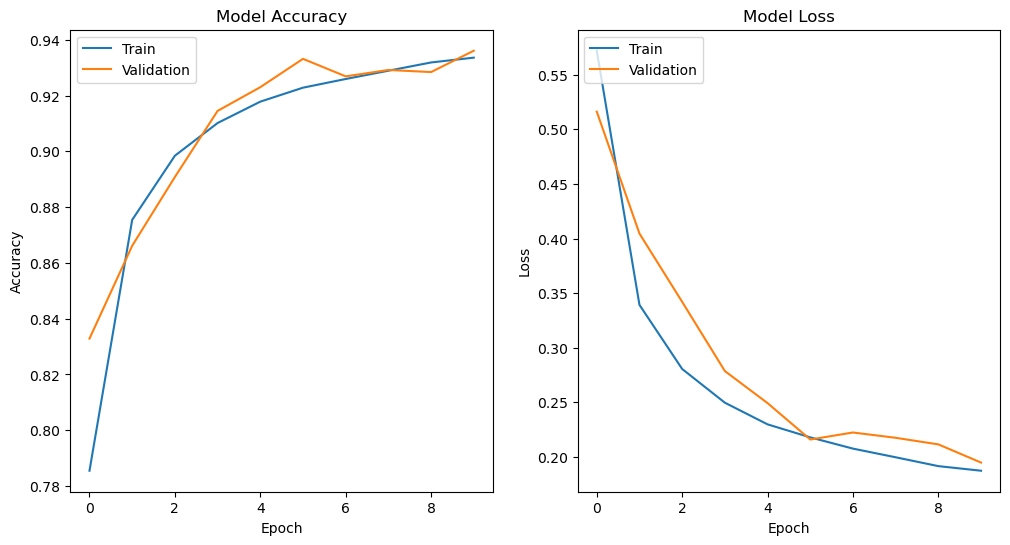

In [10]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


In [20]:
# Use SHAP to explain the model's predictions
background = X_train_reshaped[np.random.choice(X_train_reshaped.shape[0], 100, replace=False)]
explainer = shap.GradientExplainer((final_model.input, final_model.output), background)
shap_values = explainer.shap_values(X_test_reshaped[:10])

# Check shapes
print("Shape of X_test_reshaped:", X_test_reshaped[:10].shape)
print("Shape of shap_values[0]:", shap_values[0].shape)

# Visualize the SHAP values
shap.initjs()
shap.image_plot(shap_values, X_test_reshaped[:10])


TypeError: Tensors are unhashable (this tensor: KerasTensor(type_spec=TensorSpec(shape=(None, 17, 11, 1), dtype=tf.float32, name='conv2d_input'), name='conv2d_input', description="created by layer 'conv2d_input'")). Instead, use tensor.ref() as the key.

In [21]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the labels for ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
n_classes = y_test_bin.shape[1]
y_score = final_model.predict(X_test_reshaped)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(10, 7))
colors = ['blue', 'red', 'green', 'purple', 'orange']
class_names = ['N', 'S', 'V', 'F', 'Q']
for i, color, class_name in zip(range(n_classes), colors, class_names):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f'{class_name} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Class')
plt.legend(loc='lower right')
plt.show()


ValueError: Calling `Model.predict` in graph mode is not supported when the `Model` instance was constructed with eager mode enabled. Please construct your `Model` instance in graph mode or call `Model.predict` with eager mode enabled.

In [14]:
from lime import lime_image
import matplotlib.pyplot as plt

# Use LIME to explain the model's predictions
explainer = lime_image.LimeImageExplainer()

# Explain a single instance (change the index to explain different instances)
i = 0  # Index of the instance to explain
explanation = explainer.explain_instance(
    X_test_reshaped[i].reshape(17, 11),
    final_model.predict,
    top_labels=2,
    hide_color=0,
    num_samples=1000
)

# Show the explanation for label 0
temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10,
    hide_rest=False
)
plt.imshow(temp, cmap='gray')
plt.show()


  0%|          | 0/1000 [00:00<?, ?it/s]

ValueError: Calling `Model.predict` in graph mode is not supported when the `Model` instance was constructed with eager mode enabled. Please construct your `Model` instance in graph mode or call `Model.predict` with eager mode enabled.